ML Mini Project

# 1. Imports

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Saving model
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


# 2. Dataset

In [ ]:
# Download Spotify dataset directly from Kaggle

!pip install -q kagglehub

import kagglehub
import os
import glob
import pandas as pd

# Download dataset from Kaggle
path = kagglehub.dataset_download("joebeachcapital/30000-spotify-songs")

print("Dataset downloaded to:")
print(path)

# Find CSV file
csv_files = glob.glob(path + "/**/*.csv", recursive=True)

print("\nCSV files found:")
for file in csv_files:
    print(file)

100%|██████████| 3.01M/3.01M [00:00<00:00, 135MB/s]

Extracting files...
Dataset downloaded to:
/root/.cache/kagglehub/datasets/joebeachcapital/30000-spotify-songs/versions/2

CSV files found:
/root/.cache/kagglehub/datasets/joebeachcapital/30000-spotify-songs/versions/2/spotify_songs.csv


In [ ]:
# Load the Spotify dataset

csv_file = csv_files[0]

df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset loaded successfully!
Shape: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:
# Basic information about the dataset

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (32833, 23)

Column names:
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833

In [ ]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
track_name          5
track_artist        5
track_album_name    5
dtype: int64


In [ ]:
# Check our target variable: playlist_name

print("Number of unique playlists:",
      df["playlist_name"].nunique())

print("\nTop playlists:")
print(df["playlist_name"].value_counts().head(15))

Number of unique playlists: 449

Top playlists:
playlist_name
Indie Poptimism                                                                                  308
2020 Hits & 2019  Hits – Top Global Tracks 🔥🔥🔥                                                   247
Permanent Wave                                                                                   244
Hard Rock Workout                                                                                219
Ultimate Indie Presents... Best Indie Tracks of the 2010s                                        198
Fitness Workout Electro | House | Dance | Progressive House                                      195
Southern Hip Hop                                                                                 189
Charts 2020 🔥Top 2020🔥Hits 2020🔥Summer 2020🔥Pop 2020🔥Popular Music🔥Clean Pop 2020🔥Sing Alongs    189
Classic Rock 70s 80s 90s, Rock Classics - 70s Rock, 80s Rock, 90s Rock Rock  Classicos           182
Urban Contemporary           

# 3. EDA

In [ ]:
# Playlist distribution

playlist_counts = df["playlist_name"].value_counts()

print("Total unique playlists:", len(playlist_counts))

print("\nPlaylist distribution:")
print(playlist_counts.describe())

print("\nTop 20 playlists:")
print(playlist_counts.head(20))

Total unique playlists: 449

Playlist distribution:
count    449.000000
mean      73.124722
std       36.151437
min        1.000000
25%       49.000000
50%       77.000000
75%       97.000000
max      308.000000
Name: count, dtype: float64

Top 20 playlists:
playlist_name
Indie Poptimism                                                                                  308
2020 Hits & 2019  Hits – Top Global Tracks 🔥🔥🔥                                                   247
Permanent Wave                                                                                   244
Hard Rock Workout                                                                                219
Ultimate Indie Presents... Best Indie Tracks of the 2010s                                        198
Fitness Workout Electro | House | Dance | Progressive House                                      195
Southern Hip Hop                                                                                 189
Charts 2020 🔥Top 202

In [ ]:
# Check number of playlists based on minimum number of songs

for minimum in [10, 20, 50, 100, 200]:
    count = (playlist_counts >= minimum).sum()
    print(f"Playlists with at least {minimum} songs: {count}")

Playlists with at least 10 songs: 440
Playlists with at least 20 songs: 419
Playlists with at least 50 songs: 329
Playlists with at least 100 songs: 64
Playlists with at least 200 songs: 4


/tmp/ipykernel_404/4277098751.py:10: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


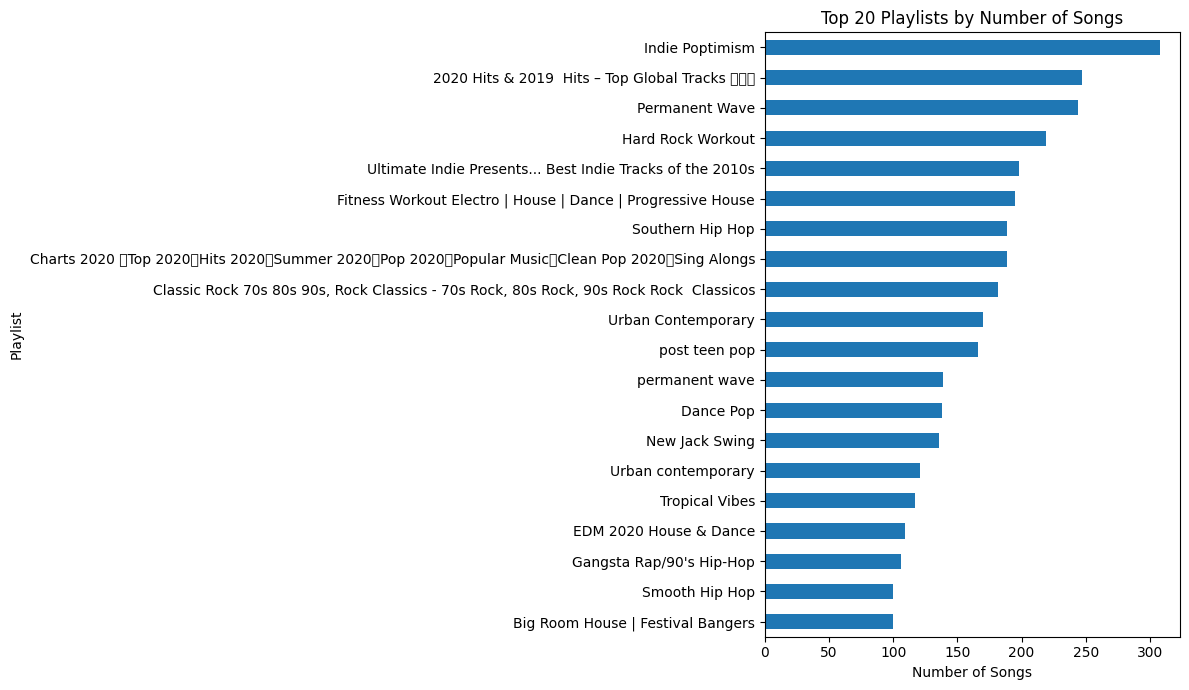

In [ ]:
# Visualize the 20 most common playlists

plt.figure(figsize=(12, 7))

playlist_counts.head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Playlists by Number of Songs")
plt.xlabel("Number of Songs")
plt.ylabel("Playlist")
plt.tight_layout()
plt.show()


# 4. Data Cleaning

In [ ]:
# Clean playlist names for consistent class labels

import re

def clean_playlist_name(name):
    # Remove emojis and special symbols
    name = re.sub(r'[^\x00-\x7F]+', '', str(name))

    # Remove extra spaces
    name = re.sub(r'\s+', ' ', name).strip()

    # Make comparison case-insensitive
    return name.casefold()

# Create cleaned playlist labels
df["playlist_clean"] = df["playlist_name"].apply(clean_playlist_name)

# Count songs using cleaned playlist names
clean_playlist_counts = df["playlist_clean"].value_counts()

# Select 13 most represented DISTINCT playlists
selected_playlists = clean_playlist_counts.head(13).index.tolist()

print("Selected 13 distinct playlists:\n")

for i, playlist in enumerate(selected_playlists, 1):
    print(f"{i}. {playlist}")

print("\nNumber of selected playlists:", len(selected_playlists))

Selected 13 distinct playlists:

1. permanent wave
2. indie poptimism
3. urban contemporary
4. post teen pop
5. electropop
6. 2020 hits & 2019 hits top global tracks
7. hard rock workout
8. trap nation
9. neo-soul
10. ultimate indie presents... best indie tracks of the 2010s
11. fitness workout electro | house | dance | progressive house
12. southern hip hop
13. charts 2020 top 2020hits 2020summer 2020pop 2020popular musicclean pop 2020sing alongs

Number of selected playlists: 13


In [ ]:
# Keep only the 13 selected playlists

df_selected = df[df["playlist_clean"].isin(selected_playlists)].copy()

print("Songs before balancing:", len(df_selected))

# Check songs available in each selected playlist
print("\nSongs per playlist:")
print(df_selected["playlist_clean"].value_counts())

Songs before balancing: 3690

Songs per playlist:
playlist_clean
permanent wave                                                                            491
indie poptimism                                                                           483
urban contemporary                                                                        457
post teen pop                                                                             317
electropop                                                                                308
2020 hits & 2019 hits top global tracks                                                   247
hard rock workout                                                                         219
trap nation                                                                               199
ultimate indie presents... best indie tracks of the 2010s                                 198
neo-soul                                                                                 

In [ ]:
# Create a balanced dataset
# 80 songs from each of the 13 playlists

df_balanced = (
    df_selected
    .groupby("playlist_clean", group_keys=False)
    .sample(n=80, random_state=42)
    .reset_index(drop=True)
)

print("Final dataset shape:", df_balanced.shape)

print("\nSongs per playlist:")
print(df_balanced["playlist_clean"].value_counts())

print("\nNumber of unique playlists:",
      df_balanced["playlist_clean"].nunique())

Final dataset shape: (1040, 24)

Songs per playlist:
playlist_clean
2020 hits & 2019 hits top global tracks                                                   80
charts 2020 top 2020hits 2020summer 2020pop 2020popular musicclean pop 2020sing alongs    80
electropop                                                                                80
fitness workout electro | house | dance | progressive house                               80
hard rock workout                                                                         80
indie poptimism                                                                           80
neo-soul                                                                                  80
permanent wave                                                                            80
post teen pop                                                                             80
southern hip hop                                                                          80
tr

In [ ]:
# Check for duplicate tracks

duplicate_track_ids = df_balanced["track_id"].duplicated().sum()

print("Duplicate track IDs:", duplicate_track_ids)

print("\nTotal rows:", len(df_balanced))
print("Unique track IDs:", df_balanced["track_id"].nunique())

Duplicate track IDs: 96

Total rows: 1040
Unique track IDs: 944


In [ ]:
# Check how many tracks occur more than once

track_frequency = df_balanced["track_id"].value_counts()

print("Tracks appearing more than once:")
print((track_frequency > 1).sum())

print("\nMaximum occurrences of a single track:",
      track_frequency.max())

Tracks appearing more than once:
83

Maximum occurrences of a single track: 4


In [ ]:
# Remove duplicate tracks

df_clean = df_balanced.drop_duplicates(
    subset="track_id",
    keep="first"
).reset_index(drop=True)

print("Dataset shape after removing duplicates:", df_clean.shape)

print("\nUnique tracks:",
      df_clean["track_id"].nunique())

print("\nSongs per playlist after removing duplicates:")
print(df_clean["playlist_clean"].value_counts())

Dataset shape after removing duplicates: (944, 24)

Unique tracks: 944

Songs per playlist after removing duplicates:
playlist_clean
electropop                                                                                80
hard rock workout                                                                         80
permanent wave                                                                            80
southern hip hop                                                                          80
neo-soul                                                                                  79
post teen pop                                                                             79
trap nation                                                                               79
indie poptimism                                                                           79
urban contemporary                                                                        77
2020 hits & 2019 hits top glob

In [ ]:
# Check class sizes after removing duplicates

class_counts = df_clean["playlist_clean"].value_counts()

print("Songs per playlist:")
print(class_counts)

print("\nSmallest playlist size:", class_counts.min())
print("Largest playlist size:", class_counts.max())

Songs per playlist:
playlist_clean
electropop                                                                                80
hard rock workout                                                                         80
permanent wave                                                                            80
southern hip hop                                                                          80
neo-soul                                                                                  79
post teen pop                                                                             79
trap nation                                                                               79
indie poptimism                                                                           79
urban contemporary                                                                        77
2020 hits & 2019 hits top global tracks                                                   61
fitness workout electro | house | d

In [ ]:
# Create final balanced dataset
# Use 52 unique songs from each playlist

df_final = (
    df_clean
    .groupby("playlist_clean", group_keys=False)
    .sample(n=52, random_state=42)
    .reset_index(drop=True)
)

print("Final dataset shape:", df_final.shape)

print("\nSongs per playlist:")
print(df_final["playlist_clean"].value_counts())

print("\nUnique tracks:", df_final["track_id"].nunique())

print("\nUnique playlists:", df_final["playlist_clean"].nunique())

Final dataset shape: (676, 24)

Songs per playlist:
playlist_clean
2020 hits & 2019 hits top global tracks                                                   52
charts 2020 top 2020hits 2020summer 2020pop 2020popular musicclean pop 2020sing alongs    52
electropop                                                                                52
fitness workout electro | house | dance | progressive house                               52
hard rock workout                                                                         52
indie poptimism                                                                           52
neo-soul                                                                                  52
permanent wave                                                                            52
post teen pop                                                                             52
southern hip hop                                                                          52
tra

# 5. Preprocessing

In [ ]:
# Select the 10 audio features used in the paper

audio_features = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "liveness",
    "valence",
    "tempo"
]

print("Selected audio features:")
for i, feature in enumerate(audio_features, 1):
    print(f"{i}. {feature}")

Selected audio features:
1. danceability
2. energy
3. key
4. loudness
5. mode
6. speechiness
7. acousticness
8. liveness
9. valence
10. tempo


In [ ]:
# Check for missing values in the selected features

print("Missing values in selected features:\n")
print(df_final[audio_features].isnull().sum())

print("\nTotal missing values:",
      df_final[audio_features].isnull().sum().sum())

Missing values in selected features:

danceability    0
energy          0
key             0
loudness        0
mode            0
speechiness     0
acousticness    0
liveness        0
valence         0
tempo           0
dtype: int64

Total missing values: 0


In [ ]:
# Create input features (X) and target variable (y)

X = df_final[audio_features].copy()
y = df_final["playlist_clean"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\nNumber of target classes:", y.nunique())

X shape: (676, 10)
y shape: (676,)

X columns:
['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo']

Number of target classes: 13


In [ ]:
# Display the first 5 feature rows and target values

print("First 5 X values:")
display(X.head())

print("\nFirst 5 y values:")
display(y.head())

First 5 X values:


,danceability,energy,key,loudness,mode,speechiness,acousticness,liveness,valence,tempo
0,0.784,0.645,10,-7.325,0,0.4020,0.00936,0.1170,0.590,109.978
1,0.760,0.479,2,-5.574,1,0.0466,0.55600,0.0703,0.913,89.911
2,0.655,0.722,0,-4.726,0,0.0480,0.55600,0.1330,0.298,90.099
3,0.602,0.377,11,-6.213,1,0.0446,0.73100,0.0808,0.518,73.877
4,0.599,0.887,4,-3.967,1,0.0984,0.01920,0.3000,0.881,170.918



First 5 y values:


,playlist_clean
0,2020 hits & 2019 hits top global tracks
1,2020 hits & 2019 hits top global tracks
2,2020 hits & 2019 hits top global tracks
3,2020 hits & 2019 hits top global tracks
4,2020 hits & 2019 hits top global tracks


# 6. Feature Engineering

In [ ]:
# Feature Engineering

df_final["energy_dance_ratio"] = (
    df_final["energy"] / (df_final["danceability"] + 1e-6)
)

df_final["acoustic_energy_ratio"] = (
    df_final["acousticness"] / (df_final["energy"] + 1e-6)
)

df_final["tempo_energy"] = (
    df_final["tempo"] * df_final["energy"]
)

print("Engineered features created successfully!")

print("\nNew features:")
print([
    "energy_dance_ratio",
    "acoustic_energy_ratio",
    "tempo_energy"
])

Engineered features created successfully!

New features:
['energy_dance_ratio', 'acoustic_energy_ratio', 'tempo_energy']


In [ ]:
# Check engineered features

engineered_features = [
    "energy_dance_ratio",
    "acoustic_energy_ratio",
    "tempo_energy"
]

display(df_final[engineered_features].head())

print("\nStatistics:")
display(df_final[engineered_features].describe())

,energy_dance_ratio,acoustic_energy_ratio,tempo_energy
0,0.822703,0.014512,70.935810
1,0.630262,1.160749,43.067369
2,1.102288,0.770082,65.051478
3,0.626245,1.938987,27.851629
4,1.480799,0.021646,151.604266



Statistics:


,energy_dance_ratio,acoustic_energy_ratio,tempo_energy
count,676.000000,676.000000,676.000000
mean,1.220707,0.467062,86.187795
std,0.610783,1.192261,34.295253
min,0.096604,0.000012,4.537088
25%,0.838295,0.010869,60.740557
50%,1.129774,0.080578,82.137599
75%,1.446137,0.412468,111.659352
max,7.623018,18.710572,194.198796


In [ ]:
# Save processed dataset for Member 2

df_final.to_csv(
    "playlist_curator_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")
print("Shape:", df_final.shape)

Processed dataset saved successfully!
Shape: (676, 27)


# 7. Train/Test Split

# 8. Baseline Models


# 9. Hyperparameter Tuning


# 10. Cross-Validation


# 11. Feature Selection


# 12. Model Comparison


# 13. Error Analysis


# 14. Explainability


# 15. Final Model


# 16. Playlist Prediction Demo